In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [19]:
np.random.seed(777)

X = np.sort(5 * np.random.rand(80, 1), axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])

#now split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

print(f"The split shows that we have {len(X_train)} training samples and {len(X_test)} testing samples")

The split shows that we have 64 training samples and 16 testing samples


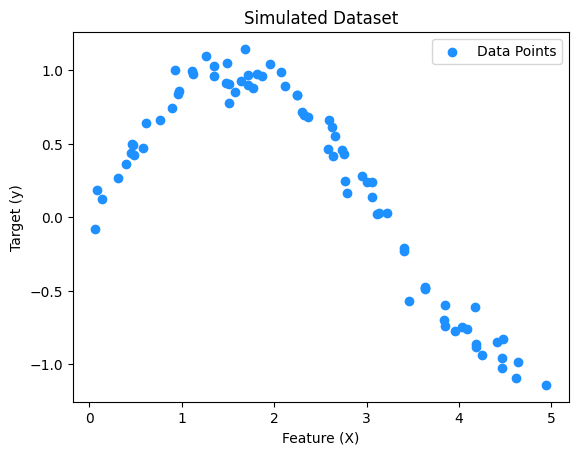

In [20]:
plt.scatter(X,y, label = "Data Points", color = "dodgerblue")
plt.xlabel("Feature (X)")
plt.ylabel("Target (y)")
plt.title("Simulated Dataset")
plt.legend()
plt.show()  

### 1. Linear Regression

In [21]:
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
lin_y_pred = lin_model.predict(X_test)
print(f"The first 5 prediction made: {lin_y_pred[:5]}")

The first 5 prediction made: [0.48904148 1.19543846 0.60771859 0.47198201 0.6983623 ]


Performance Evaluation

In [31]:
from sklearn.metrics import *
lin_mse = mean_squared_error(y_test, lin_y_pred)
lin_r2 = r2_score(y_test, lin_y_pred)
print(f"The mean squared error for the linear regression model is: {lin_mse:.3f}")
print(f"The R-squared for the linear regression model is: {lin_r2:.3f}")
X_sorted = np.sort(X, axis=0)


The mean squared error for the linear regression model is: 0.275
The R-squared for the linear regression model is: 0.391


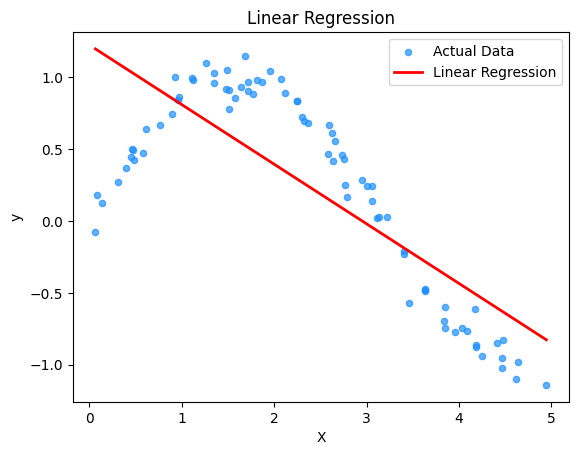

In [42]:
lin_pred = lin_model.predict(X_sorted)
plt.scatter(X, y, color="dodgerblue", s=20, alpha = 0.7, label="Actual Data")
plt.plot(X_sorted, lin_pred, color="red", linewidth=2, label="Linear Regression")
plt.title("Linear Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()

With the low R squared for the model, this shows that the linear regression is not the best way to predict and create a model with, as it would not provide a substantial answer that is based on the data.

### 2. Decision Tree Model

In [24]:
from sklearn.tree import DecisionTreeRegressor

In [26]:
tree_model = DecisionTreeRegressor(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [35]:
tree_pred = tree_model.predict(X_test)

for i in range(5):
    print(f"Predicted: {tree_pred[i]:.3f}, Actual: {y_test[i]:.3f}")

Predicted: 0.928, Actual: 0.883
Predicted: 0.155, Actual: -0.076
Predicted: 0.928, Actual: 1.050
Predicted: 0.928, Actual: 0.977
Predicted: 0.928, Actual: 1.095


Performance Evaluation

In [37]:
tree_mse = mean_squared_error(y_test, tree_pred)
tree_r2 = r2_score(y_test, tree_pred)
print(f"The mean squared error for the decision tree model is: {tree_mse:.3f}")
print(f"The R-squared for the decision tree model is: {tree_r2:3f}")

The mean squared error for the decision tree model is: 0.020
The R-squared for the decision tree model is: 0.954758


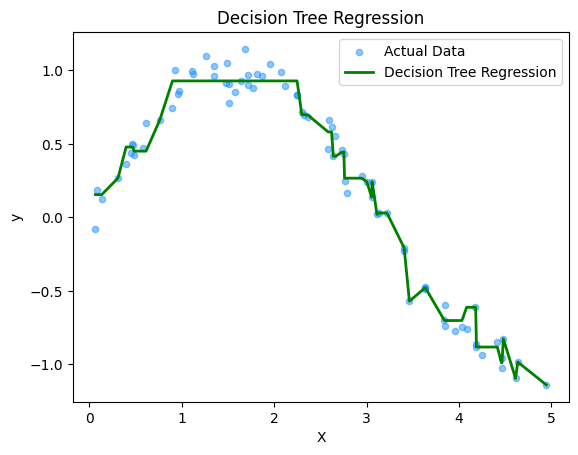

In [40]:
tree_pred = tree_model.predict(X_sorted)
plt.scatter(X,y, color = "dodgerblue", s=20, alpha = 0.5, label = "Actual Data")
plt.plot(X_sorted, tree_pred, color = "green", linewidth=2, label = "Decision Tree Regression")
plt.title("Decision Tree Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

### 3. K - Nearest Neighbor

In [44]:
from sklearn.neighbors import KNeighborsRegressor
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [45]:
knn_y_pred = knn_model.predict(X_test)

for i in range(5):
    print(f"Predicted: {knn_y_pred[i]:.3f}, Actual: {y_test[i]:.3f}")

Predicted: 0.959, Actual: 0.883
Predicted: 0.304, Actual: -0.076
Predicted: 0.896, Actual: 1.050
Predicted: 0.959, Actual: 0.977
Predicted: 0.976, Actual: 1.095


Performance Evaluation

In [46]:
knn_mse = mean_squared_error(y_test, knn_y_pred)
knn_r2 = r2_score(y_test, knn_y_pred)
print(f"The mean squared error for the KNN model is: {knn_mse:.3f}")
print(f"The R-squared for the KNN model is: {knn_r2:3f}")

The mean squared error for the KNN model is: 0.018
The R-squared for the KNN model is: 0.960385


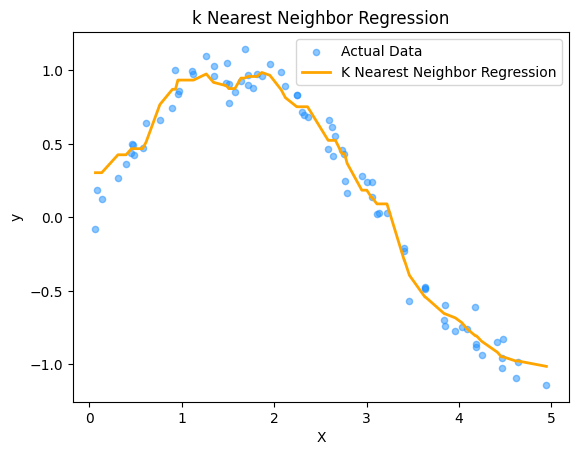

In [49]:
knn_pred = knn_model.predict(X_sorted)
plt.scatter(X,y, color = "dodgerblue", s=20, alpha = 0.5, label = "Actual Data")
plt.plot(X_sorted, knn_pred, color = "orange", linewidth=2, label = "K Nearest Neighbor Regression")
plt.title("k Nearest Neighbor Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

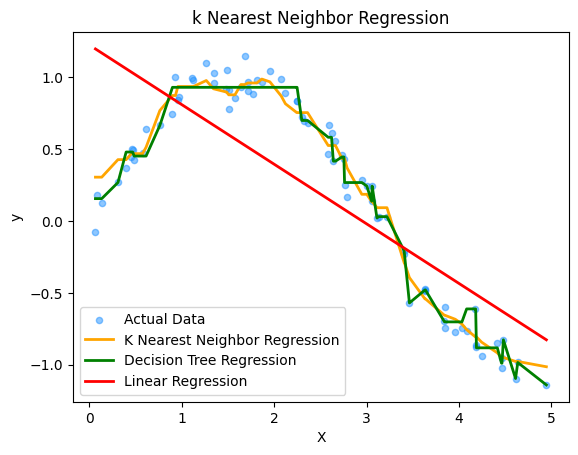

In [51]:
knn_pred = knn_model.predict(X_sorted)
plt.scatter(X,y, color = "dodgerblue", s=20, alpha = 0.5, label = "Actual Data")
plt.plot(X_sorted, knn_pred, color = "orange", linewidth=2, label = "K Nearest Neighbor Regression")
plt.plot(X_sorted, tree_pred, color = "green", linewidth=2, label = "Decision Tree Regression")
plt.plot(X_sorted, lin_pred, color="red", linewidth=2, label="Linear Regression")
plt.title("k Nearest Neighbor Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()